<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Quantum005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 64
lambda_void = 1.0
e_folds = 13800  # Gyr equivalent


In [ ]:
def generate_spinor_loop(grid_size):
    # Topological winding: 4π loop
    x = np.linspace(0, 2*np.pi, grid_size)
    y = np.linspace(0, 2*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X) * np.cos(Y)

def generate_vector_field(grid_size):
    # Directional memory
    return np.tile(np.linspace(-1, 1, grid_size), (grid_size,1))

def generate_tensor_shear(grid_size):
    # Transverse-traceless projection
    field = np.zeros((grid_size, grid_size))
    for i in range(grid_size):
        field[i, i] = 1.0
        field[i, grid_size - i - 1] = -1.0
    return field


In [ ]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [ ]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Spinor Loop fidelity after 13800 e-folds: 0.8750


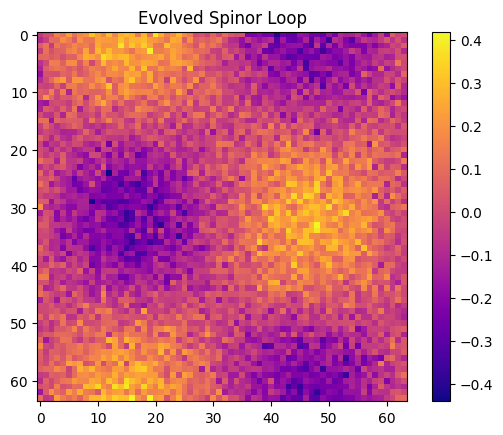

Vector Field fidelity after 13800 e-folds: 0.9083


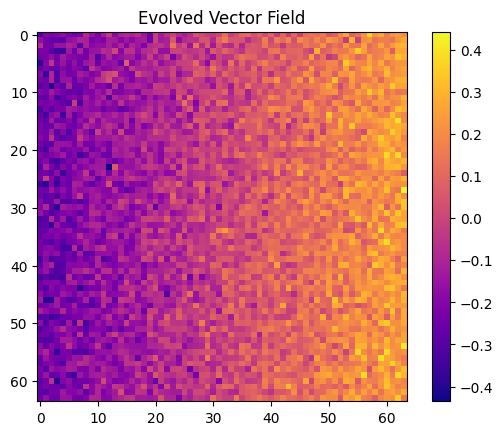

Tensor Shear fidelity after 13800 e-folds: 0.5439


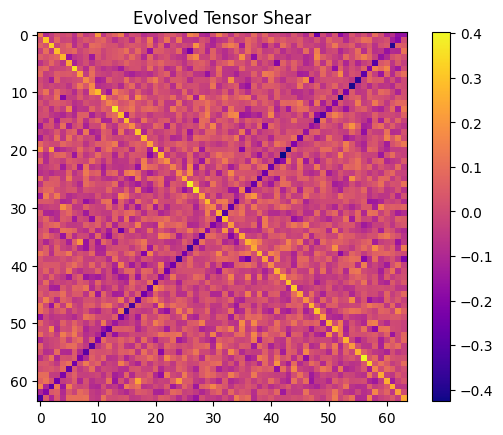

In [ ]:
fields = {
    "Spinor Loop": generate_spinor_loop(grid_size),
    "Vector Field": generate_vector_field(grid_size),
    "Tensor Shear": generate_tensor_shear(grid_size)
}

for name, field in fields.items():
    evolved = evolve_field(field, e_folds)
    fidelity = memory_fidelity(field, evolved)
    print(f"{name} fidelity after {e_folds} e-folds: {fidelity:.4f}")
    plt.imshow(evolved, cmap='plasma')
    plt.title(f"Evolved {name}")
    plt.colorbar()
    plt.show()
